# Notebook 3 — Modeling the licks

*SWC ENC 2026 · behaviour module*

We can now build the design matrix $X$ (Notebook 1) and we've seen strategies
leave fingerprints in behavior (Notebook 2). But so far we *peeked at ground
truth* to know each mouse's strategy. This notebook is where we stop peeking and
**infer** the strategy from behavior, by fitting the model the paper is built on:
**logistic regression**.

**In this notebook you will:**
1. Write down the model and its **likelihood**.
2. Fit it by **maximizing** that likelihood.
3. **Recover** the true strategy weights of single-strategy mice.
4. See what a single static fit does to the *dynamic* mouse — the crack that
   motivates the rest of the day.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
import swcbehav as sb

def get_Xy(sess):
    # Observable design matrix X and per-image outcome y for a session.
    X, cols = sb.build_design_matrix(sess.table)
    y = sess.table["bout_start"].to_numpy().astype(float)
    return X, y, cols

## 1. One image at a time: the Bernoulli model

Start with a single image. The model turns its design row $x_t$ and the weights
$w$ into a probability that a licking bout starts on it:

$$p_t = \sigma(w \cdot x_t), \qquad \sigma(z) = \frac{1}{1 + e^{-z}} .$$

The outcome $y_t$ is binary — a bout either starts ($y_t = 1$) or it doesn't
($y_t = 0$) — so one image is a biased coin flip. The distribution of a single
yes/no outcome with success probability $p_t$ is the **Bernoulli distribution**:

$$P(y_t \mid p_t) =
\begin{cases} p_t & \text{if } y_t = 1 \\ 1 - p_t & \text{if } y_t = 0 \end{cases}
\;=\; p_t^{\,y_t}\,(1 - p_t)^{\,1 - y_t}.$$

The compact form on the right packs both cases into one expression, using the
fact that anything to the power $0$ is $1$: when $y_t = 1$ it reduces to $p_t$;
when $y_t = 0$ it reduces to $1 - p_t$. Either way it is the probability the model
assigns to *what the mouse actually did* on image $t$.

## 2. A whole session: independence makes a product

We don't have one image, we have thousands. The **likelihood** is the probability
the model assigns to the *entire* observed sequence of outcomes, read as a
function of the weights $w$:

$$\mathcal{L}(w) = P(y_1, y_2, \dots, y_T \mid w).$$

To get from one image to the whole sequence we make a modeling assumption: the
outcomes are **conditionally independent given the weights and the stimulus**.
"Independent" here means that once $w$ and the design rows are fixed, knowing a
bout started on image 5 tells us nothing *extra* about image 6 — whatever one
image implies about the next is already carried in the design matrix (that is
exactly the job of the timing regressor). Independence is precisely the condition
that lets us **multiply** the per-image probabilities together:

$$\mathcal{L}(w) = \prod_{t=1}^{T} p_t^{\,y_t}\,(1 - p_t)^{\,1 - y_t}.$$

(It's an idealization — real licking surely has leftover dependencies — but it is
the assumption the model is built on, and what makes the problem tractable.)

## 3. Why we work with the log

That product is a clean mathematical object but a terrible one to compute. With
$T \approx 4800$ images, every factor is a probability below $1$, and multiplying
thousands of them **underflows to zero** in floating point — the true value is
smaller than the computer can represent. Taking the **logarithm** cures this and
brings two more benefits:

* $\log$ turns the product into a **sum**, which can't underflow and is far easier
  to differentiate (we'll need that to fit);
* $\log$ is monotonically increasing, so the $w$ that maximizes $\mathcal{L}(w)$ is
  the *same* $w$ that maximizes $\log \mathcal{L}(w)$ — switching to the log costs
  us nothing.

The log of the product becomes a sum of logs — the **log-likelihood**:

$$\log \mathcal{L}(w) = \sum_{t=1}^{T} \Big[\, y_t \log p_t + (1 - y_t)\log(1 - p_t)\,\Big].$$

Substituting $p_t = \sigma(w\cdot x_t)$ and simplifying (worth grinding through
once by hand) removes the $\sigma$ entirely and gives the form we actually code:

$$\log \mathcal{L}(w) = \sum_{t=1}^{T} \Big[\, y_t\,(w\cdot x_t) - \log\!\big(1 + e^{\,w\cdot x_t}\big) \Big].$$

This version is also numerically safer: it never forms $p_t$ and then logs it
(which blows up for confident predictions). The awkward $\log(1 + e^z)$ term has
its own stable routine, `np.logaddexp(0, z)`.

**Exercise 1.** Implement this log-likelihood inside `neg_log_likelihood`. We
return the *negative* log-likelihood because the optimizer in the next step
minimizes rather than maximizes. The extra `l2` term adds a small penalty on large
weights — a weak Gaussian **prior** that keeps the fit well-behaved and turns pure
maximum-likelihood into the *maximum a posteriori* (MAP) estimate the paper uses;
leave it as given.

> **Check / unstuck.** The next cell should print **NLL at w=0 ≈ 3327**, matching
> `n·log(0.5)`. Stuck? Use `sb.neg_log_likelihood`.

In [2]:
def neg_log_likelihood(w, X, y, l2=1e-4):
    z = X @ w                                   # w . x for every image
    log_lik = np.sum(y * z - np.logaddexp(0.0, z))
    return -log_lik + l2 * np.sum(w ** 2)       # ridge = weak Gaussian prior (MAP)

In [3]:
# Sanity check: at w = 0 every p_t = 0.5, so the log-likelihood is n*log(0.5).
Xv, yv, cols = get_Xy(sb.make_mouse("visual", seed=0))
w0 = np.zeros(Xv.shape[1])
print("NLL at w=0:", round(neg_log_likelihood(w0, Xv, yv), 1))
print("expected  :", round(-len(yv) * np.log(0.5), 1))

NLL at w=0: 3327.1
expected  : 3327.1


## 4. Maximizing the likelihood

Fitting the model means choosing the weights under which the mouse's actual
licking was **most probable** — the $w$ that maximizes $\log \mathcal{L}(w)$, or
equivalently *minimizes* the negative log-likelihood we just built.

How do we find that $w$? The negative log-likelihood is a smooth function of the
weights, so at any point we can compute its **gradient** — the direction in
weight-space in which it rises fastest — and step the opposite way to go downhill.
Repeating that is **gradient descent**: start from a guess, measure the slope,
take a step down, and iterate until the slope flattens out. For logistic
regression the gradient takes a tidy, interpretable form,

$$\nabla\big(\!-\log\mathcal{L}\big) = \sum_t (p_t - y_t)\,x_t,$$

so each image pushes the weights in proportion to its **prediction error**
$(p_t - y_t)$ — images the model got wrong pull hardest. And this objective is
**convex** (bowl-shaped, no local minima to trap us), so gradient descent is
guaranteed to reach the single global optimum.

Plain gradient descent only uses the slope and can zig-zag slowly toward the
bottom. We can converge in far fewer steps by also using **curvature** — how the
slope is itself changing — to pick smarter step directions and sizes. That is what
the optimizer we'll call, **L-BFGS-B**, does; treat it as a black box whose one-line
summary is "gradient descent that also exploits curvature." `scipy.optimize.minimize`
even estimates the gradient for us here — in Notebook 7 we'll supply one by hand.

**Exercise 2.** Complete `fit_static` using `scipy.optimize.minimize` with
`method="L-BFGS-B"`, starting from an all-zeros weight vector.

> **Check / unstuck.** The visual mouse should recover **bias ≈ −3, visual ≈ 5**,
> the rest ≈ 0. Stuck? Use `sb.fit_static`.

In [4]:
def fit_static(X, y, l2=1e-4):
    result = minimize(neg_log_likelihood, np.zeros(X.shape[1]),
                      args=(X, y, l2), method="L-BFGS-B")
    return result.x

In [5]:
w_fit = fit_static(Xv, yv)
w_true = sb.make_mouse("visual", seed=0).true_weights[0]
print(f"{'strategy':14s}{'true':>7s}{'fit':>8s}")
for c, t, f in zip(cols, w_true, w_fit):
    print(f"{c:14s}{t:7.1f}{f:8.2f}")

strategy         true     fit
bias             -3.0   -2.96
visual            5.0    5.03
omission          0.0   -0.12
post_omission     0.0   -0.46
timing            0.0   -0.17


The fit puts nearly all the weight on **visual**, with bias near $-3$ and the
other strategies near zero — it has **recovered the strategy from behavior
alone**, without ever seeing the true weights. This "can we recover the truth?"
check is the backbone of the whole course.

## 5. Recovery across strategies

Does it work for every single-strategy mouse? Fit all three and compare fitted to
true weights.

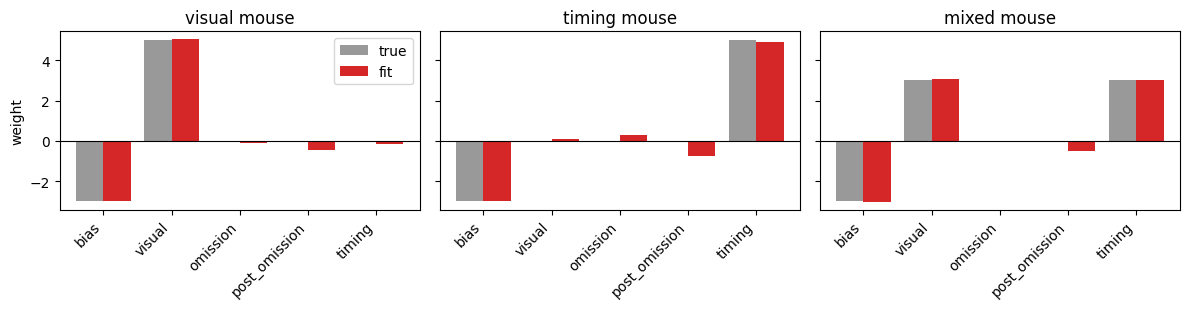

In [6]:
archetypes = ["visual", "timing", "mixed"]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
xpos = np.arange(len(cols))
for ax, name in zip(axes, archetypes):
    sess = sb.make_mouse(name, seed=0)
    X, y, _ = get_Xy(sess)
    w_fit = fit_static(X, y)
    w_true = sess.true_weights[0]
    ax.bar(xpos - 0.2, w_true, 0.4, label="true", color="0.6")
    ax.bar(xpos + 0.2, w_fit, 0.4, label="fit", color="tab:red")
    ax.set_xticks(xpos); ax.set_xticklabels(cols, rotation=45, ha="right")
    ax.axhline(0, color="k", lw=0.8); ax.set_title(f"{name} mouse")
axes[0].set_ylabel("weight"); axes[0].legend()
plt.tight_layout(); plt.show()

Fitted bars track the true bars across all three mice. A few things worth saying
out loud:

* The weights are **log-odds**. A bias of $-3$ means a baseline bout probability
  of $\sigma(-3) \approx 0.05$; adding a visual weight of $+5$ on a change image
  gives $\sigma(-3 + 5) = \sigma(2) \approx 0.88$ — the hit rate we measured in
  Notebook 2.
* The **omission** and **post-omission** weights wobble more around their true
  value of zero. Those events are rare, so there's little data to pin them down —
  the same reason the paper found the omission strategy weakly determined.

## 6. A single fit meets the dynamic mouse

Everything above assumed the strategy is *fixed*. What happens if we fit one
static $w$ to the **dynamic** mouse, whose strategy drifts? The optimizer returns
the single weight vector that best explains the whole hour at once — a blurry
average that lands *between* visual and timing and matches the animal at no point
in particular.

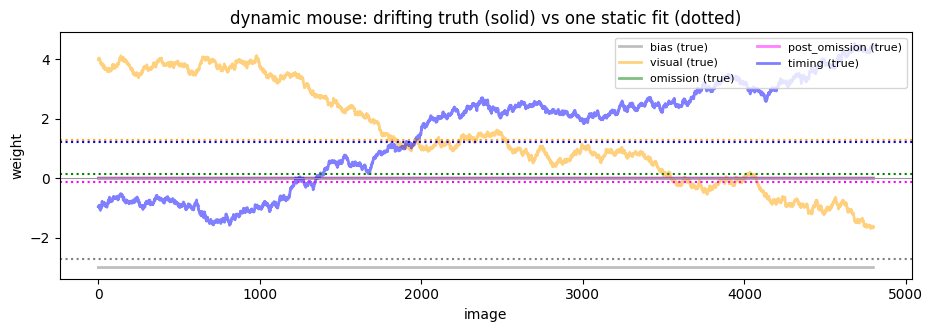

static fit visual = 1.27  timing = 1.22


In [7]:
dyn = sb.make_mouse("dynamic", seed=1)
Xd, yd, _ = get_Xy(dyn)
w_static = fit_static(Xd, yd)

sb.plotting.plot_weights(true_weights=dyn.true_weights, col_names=sb.WEIGHT_NAMES)
for k, name in enumerate(sb.WEIGHT_NAMES):
    plt.axhline(w_static[k], color=sb.WEIGHT_COLORS[name], ls=":", lw=1.5)
plt.title("dynamic mouse: drifting truth (solid) vs one static fit (dotted)")
plt.show()
print("static fit visual =", round(w_static[1], 2),
      " timing =", round(w_static[4], 2))

The dotted static estimates sit flat while the true visual and timing weights
cross right past them. The model isn't wrong — it's answering the wrong question,
forcing one number onto a moving target.

## Wrap-up

You built the strategy model from its likelihood, fit it by maximizing that
likelihood, and recovered the true weights of single-strategy mice. You also saw
the static model's blind spot: a mouse whose strategy changes.

**Next (Notebook 4):** before trusting any of these fits, we need to *evaluate*
them — how well does the model actually predict held-out licking? That's the ROC
curve, AUC, and cross-validation.